## import libraries and data

In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import matplotlib.pyplot as plt
from src.extraction import load_processed, FEATURE_COLUMNS, save_model, load_model
from src.classification import build_X_y, split_data, analyze_imbalance, train_model,evaluate_models, plot_all_confusion_matrices, plot_f1_comparison, cross_validate_models, plot_cv_boxplot, tune_models, select_best_model, get_feature_importance, plot_feature_importance
from sklearn.metrics import classification_report

df_clean_clusters = load_processed("df_clean_with_target.csv")
df_clean_clusters = df_clean_clusters[FEATURE_COLUMNS + ["target"]]

df_clean_clusters

,BALANCE,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,target
0,40.900749,95.40,0.00,95.40,0.000000,1000.0,201.802084,Clients à Faible Activité
1,3202.467416,0.00,0.00,0.00,6442.945483,7000.0,4103.032597,Clients à Risque
2,2495.148862,773.17,773.17,0.00,0.000000,7500.0,622.066742,Clients Premium
3,1666.670542,1499.00,1499.00,0.00,205.788017,7500.0,0.000000,Clients à Faible Activité
4,817.714335,16.00,16.00,0.00,0.000000,1200.0,678.334763,Clients à Faible Activité
...,...,...,...,...,...,...,...,...
8944,28.493517,291.12,0.00,291.12,0.000000,1000.0,325.594462,Clients à Faible Activité
8945,19.183215,300.00,0.00,300.00,0.000000,1000.0,275.861322,Clients à Faible Activité
8946,23.398673,144.40,0.00,144.40,0.000000,1000.0,81.270775,Clients à Faible Activité
8947,13.457564,0.00,0.00,0.00,36.558778,500.0,52.549959,Clients à Faible Activité


## Build X / y and stratified train/test split

In [2]:
X, y = build_X_y(df_clean_clusters)

X_train, X_test, y_train, y_test = split_data(X, y)

# check if the Stratification have the same proportions
display(pd.DataFrame({
    "train" : y_train.value_counts(normalize=True),
    "test"  : y_test.value_counts(normalize=True)
}))

,train,test
target,,
Clients Premium,0.399078,0.398883
Clients à Faible Activité,0.333706,0.334078
Clients à Risque,0.267216,0.267039


## Class imbalance analysis

In [3]:
table, ratio, needs_resampling = analyze_imbalance(y_train)
display(table)
print(f"Imbalance ratio (largest / smallest): {ratio}")
print("Resampling needed:", needs_resampling)

SAMPLING = "over" if needs_resampling else "none"
print("Sampling strategy used in the pipeline:", SAMPLING)

,count,pct
target,,
Clients Premium,2857,39.9
Clients à Faible Activité,2389,33.4
Clients à Risque,1913,26.7


Imbalance ratio (largest / smallest): 1.49
Resampling needed: False
Sampling strategy used in the pipeline: none


## Training the 4 pipelines

In [4]:
pipelines, train_times = train_model(X_train, y_train, sampling=SAMPLING)

display(train_times)

for name, pipeline in pipelines.items():
    print(f"{name} test accuracy = {pipeline.score(X_test, y_test):.3f}")

pipelines["svm"]

,train_time_s
model,
random_forest,0.616
svm,2.474
decision_tree,0.097
logistic_regression,0.241


random_forest test accuracy = 0.971
svm test accuracy = 0.906
decision_tree test accuracy = 0.947
logistic_regression test accuracy = 0.902


,steps,"[('scaler', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[object](3,)","['Clients Premium','Clients à Faible Activité','Clients à Risque']"
feature_names_in_,"ndarray[object](7,)","['BALANCE','PURCHASES','ONEOFF_PURCHASES',...,'CASH_ADVANCE', 'CREDIT_LIMIT','PAYMENTS']"
n_features_in_,int,7
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


## Evaluation on the test set,

In [5]:
comparison = evaluate_models(pipelines, X_test, y_test, train_times)
display(comparison)

for name, pipeline in pipelines.items():
    print(f"===== {name} =====")
    print(classification_report(y_test, pipeline.predict(X_test), digits=3))

,accuracy,precision_macro,recall_macro,f1_macro,train_time_s
model,,,,,
random_forest,0.9709,0.9716,0.9713,0.9715,0.616
decision_tree,0.9475,0.9470,0.9492,0.9481,0.097
svm,0.9061,0.9035,0.9118,0.9062,2.474
logistic_regression,0.9017,0.9008,0.9076,0.9030,0.241


===== random_forest =====
                           precision    recall  f1-score   support

          Clients Premium      0.972     0.969     0.971       714
Clients à Faible Activité      0.962     0.970     0.966       598
         Clients à Risque      0.981     0.975     0.978       478

                 accuracy                          0.971      1790
                macro avg      0.972     0.971     0.971      1790
             weighted avg      0.971     0.971     0.971      1790

===== svm =====
                           precision    recall  f1-score   support

          Clients Premium      0.957     0.870     0.911       714
Clients à Faible Activité      0.883     0.910     0.896       598
         Clients à Risque      0.870     0.956     0.911       478

                 accuracy                          0.906      1790
                macro avg      0.903     0.912     0.906      1790
             weighted avg      0.909     0.906     0.906      1790

===== decision

In [6]:
##

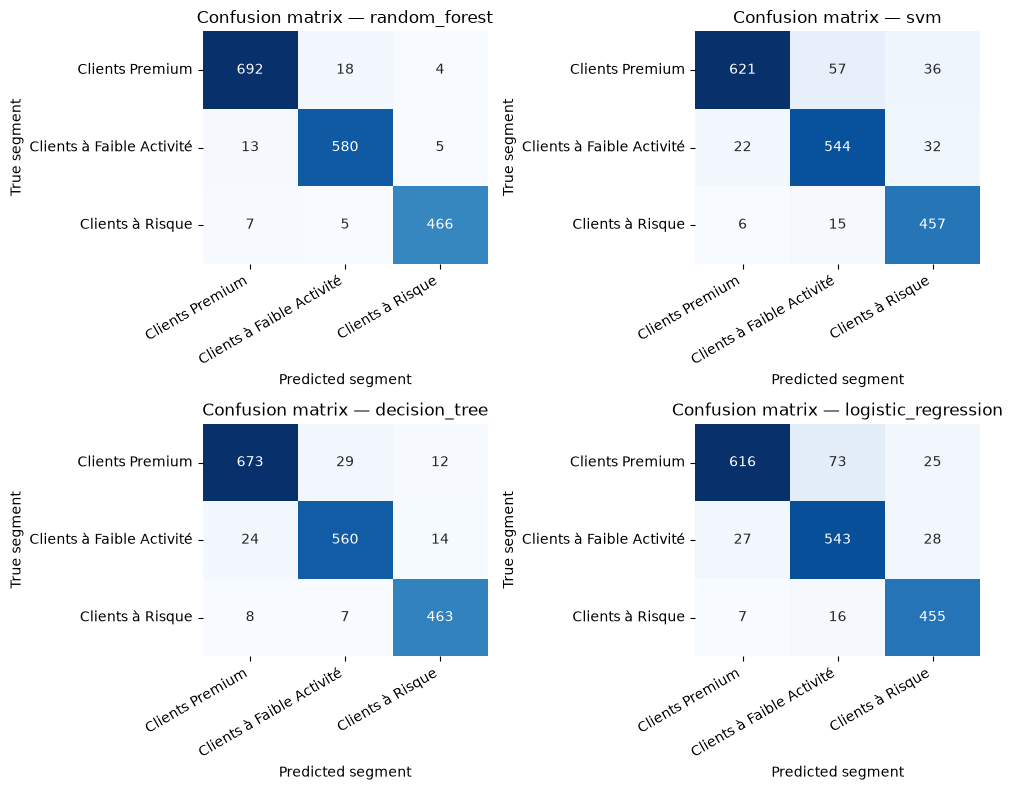

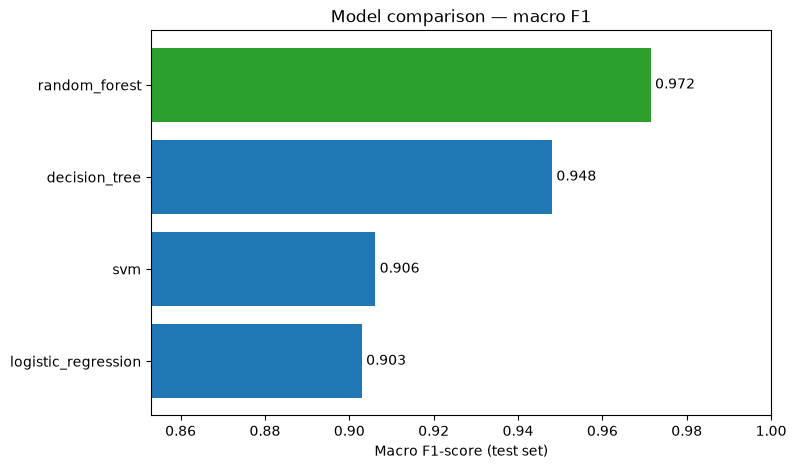

In [7]:
plot_all_confusion_matrices(pipelines, X_test, y_test)
plt.show()

plot_f1_comparison(comparison)
plt.show()

## Cross-validation (stability)

,mean,std,min,max
model,,,,
random_forest,0.9679,0.0060,0.9610,0.9752
decision_tree,0.9473,0.0042,0.9411,0.9522
svm,0.9077,0.0054,0.9012,0.9135
logistic_regression,0.9040,0.0084,0.8926,0.9163


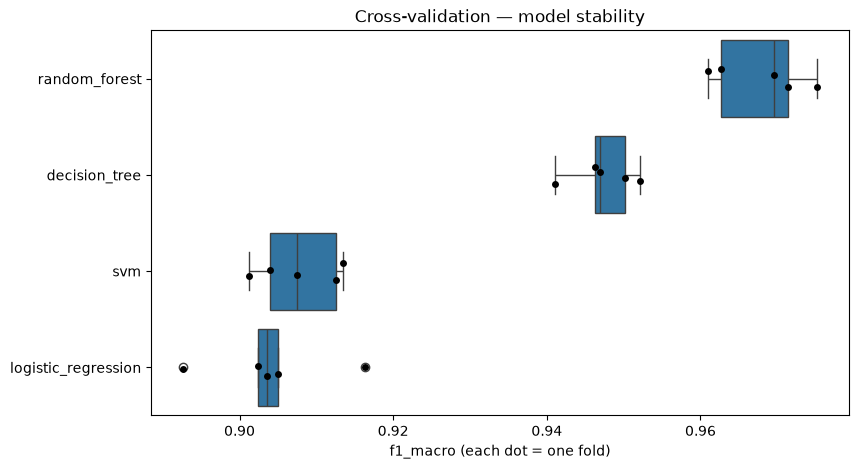

In [8]:
cv_scores = cross_validate_models(X_train, y_train, sampling=SAMPLING)

summary = (cv_scores.groupby("model")["f1_macro"]
           .agg(["mean", "std", "min", "max"])
           .sort_values("mean", ascending=False).round(4))
display(summary)

plot_cv_boxplot(cv_scores)
plt.show()

## Hyperparameter tuning

In [9]:
tuned_pipelines, tuning_summary = tune_models(X_train, y_train, sampling=SAMPLING, search="random", n_iter=20)
display(tuning_summary)

tuned_comparison = evaluate_models(
    tuned_pipelines, X_test, y_test,
    train_times=tuning_summary[["search_time_s"]],
)
display(tuned_comparison)

,best_cv_f1_macro,best_params,search_time_s
model,,,
random_forest,0.9690,"{'classifier__n_estimators': 400, 'classifier_...",22.6
decision_tree,0.9487,"{'classifier__min_samples_leaf': 1, 'classifie...",0.9
svm,0.9403,"{'classifier__estimator__gamma': 'scale', 'cla...",34.8
logistic_regression,0.9123,{'classifier__C': 10},0.4


,accuracy,precision_macro,recall_macro,f1_macro,search_time_s
model,,,,,
random_forest,0.9754,0.9755,0.9758,0.9757,22.6
decision_tree,0.9475,0.9465,0.9492,0.9478,0.9
svm,0.9380,0.9368,0.9409,0.9386,34.8
logistic_regression,0.9073,0.9071,0.9125,0.9092,0.4


## Best model, feature importance, saving,

Best model: random_forest
Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier',
                 RandomForestClassifier(min_samples_leaf=2, n_estimators=400,
                                        n_jobs=-1, random_state=42))])


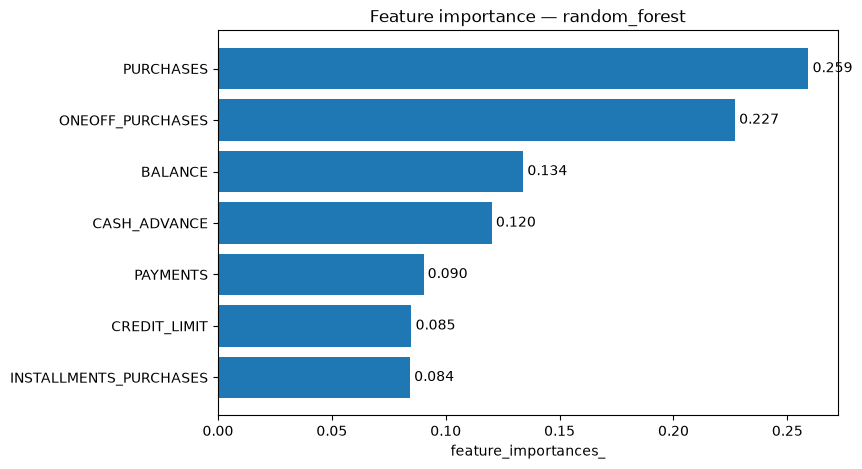

Saved to: /home/ouelaimar/Desktop/CardProfiler/models/best_pipeline.joblib


In [10]:
best_name, best_pipeline = select_best_model(tuned_comparison, tuned_pipelines)
print("Best model:", best_name)
print(best_pipeline)

importance = get_feature_importance(best_pipeline, X_test, y_test)
plot_feature_importance(importance, best_name)
plt.show()

path =  save_model(best_pipeline, "best_pipeline.joblib")
print("Saved to:", path)


## MLflow tracking

In [12]:
from src.tracking import setup_mlflow, log_runs

setup_mlflow()

runs = log_runs(
    tuned_pipelines, X_test, y_test, best_params=tuning_summary["best_params"].to_dict(),extra_params={"sampling": SAMPLING, "search": "grid"},
)

display(runs.sort_values("f1_macro", ascending=False))

,run_id,accuracy,precision_macro,recall_macro,f1_macro
model,,,,,
random_forest,5b167ef5ebdc417d97e396a8e94f56fa,0.9754,0.9755,0.9758,0.9757
decision_tree,9348537cfffe4ed497519434dfdd19ba,0.9475,0.9465,0.9492,0.9478
svm,f9f2e608754647378aa9f44a64f8c3e6,0.9380,0.9368,0.9409,0.9386
logistic_regression,aea58f85484c44b7bceba4ca0e963502,0.9073,0.9071,0.9125,0.9092
